In [2]:
import pandas as pd

import numpy as np
import pylab as plt

import seaborn as sns
sns.set(font_scale=0.9)
sns.set_style("white")

pd.options.display.max_columns = 100

#import the functions in data_processing
from data_processing import *


In [3]:
dev_haven = ["NLD","CHE","SGP","IRL","HKG"]
island_states = "CYM, BMU, PRI, JEY, BHS, IMN, BRB, GIB, LUX, UK_Caribbean, BEA_Other_Europe, BEA_Other_Western, VGB, MUS, MLT".split(", ")

# 2. An exploration of double ocunting

In [4]:
df = pd.read_csv("data/combined_dataset.tsv",sep="\t",index_col=None)
df["pi_original"] = df["pi"].copy()
df = df.loc[df["year"]< 2022]
#CUW is repeated (NLD islands and Curacao)
df = df.drop_duplicates(subset=["iso","year","source","type"])
df.head()

,iso,year,pi,source,type,emp,wages,at,t_at,txt,revenue_unrelated,revenue_total,net_interest,etr,n_groups,n_firms,accum_earnings,revenue_related,txc,capital,dom,pi_original
0,ABW,2004,NaN,BEA_income,all_groups,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,2005,NaN,BEA_income,all_groups,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,2006,NaN,BEA_income,all_groups,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,2007,NaN,BEA_income,all_groups,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,2008,NaN,BEA_income,all_groups,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
include_stateless = False
all_countries = False

if include_stateless:
    if all_countries:
        poss = list(set(df["iso"].unique()) - {"Rest","USA","Stateless"})
        print(poss)
    else:
        poss = ["BMU","GBR","NLD","SGP","CHE","HKG","CYM","JEY","GIB","IMN","BRB","VGB","LUX", "MUS","PRI","MLT",'BHS',"IRL"]#"MAC","GGY",
    ", ".join([iso3_to_name(_) for _ in poss])
    
else:
    if all_countries:
        poss = list(set(df["iso"].unique()) - {"Rest","USA","IRL","Stateless"})
        print(poss)
    else:
        poss = ["BMU","GBR","NLD","SGP","CHE","HKG","CYM","JEY","GIB","IMN","BRB","VGB","LUX", "MUS","PRI","MLT",'BHS']#,"IRL"]#"MAC","GGY",
        ", ".join([iso3_to_name(_) for _ in poss])
    

In [6]:

#Fix CBCR
#Domestic
double_counting_dom_17 = 415
double_counting_for_17 = 246

double_counting_dom_18 = 632
double_counting_for_18 = 457


double_counting_dom_19 = 385
double_counting_for_19 = 331

# df.loc[(df["iso"]=="USA")&(df["source"]=="CBCR")&(df["year"]==2016),"pi"] -= 357E9
df.loc[(df["iso"]=="USA")&(df["source"]=="CBCR")&(df["year"]==2017),"pi"] -= double_counting_dom_17*1E9
df.loc[(df["iso"]=="USA")&(df["source"]=="CBCR")&(df["year"]==2018),"pi"] -= double_counting_dom_18*1E9
df.loc[(df["iso"]=="USA")&(df["source"]=="CBCR")&(df["year"]==2019),"pi"] -= double_counting_dom_19*1E9

# df.loc[(df["iso"]=="Rest")&(df["source"]=="CBCR")&(df["year"]==2016),"pi"] -= 122E9
df.loc[(df["iso"]=="Rest")&(df["source"]=="CBCR")&(df["year"]==2017),"pi"] -= double_counting_for_17*1E9
df.loc[(df["iso"]=="Rest")&(df["source"]=="CBCR")&(df["year"]==2018),"pi"] -= double_counting_for_18*1E9
df.loc[(df["iso"]=="Rest")&(df["source"]=="CBCR")&(df["year"]==2019),"pi"] -= double_counting_for_19*1E9

if include_stateless:
    # #Add 50% of stateless to Ireland, 20% to LUX
    cols = [col for (col,d) in zip(df.columns,df.dtypes) if (d==float) and (col!="pi_original") and (col!="wages")]
    df.loc[(df["source"]=="CBCR")&(df["iso"]=="IRL"),cols] = df.loc[(df["source"]=="CBCR")&(df["iso"]=="IRL"),cols].values + df.loc[(df["source"]=="CBCR")&(df["iso"]=="Stateless"),cols].values*0.5
    df.loc[(df["source"]=="CBCR")&(df["iso"]=="LUX"),cols] = df.loc[(df["source"]=="CBCR")&(df["iso"]=="LUX"),cols].values + df.loc[(df["source"]=="CBCR")&(df["iso"]=="Stateless"),cols].values*0.2
    df.loc[(df["source"]=="CBCR")&(df["iso"]=="Stateless"),cols] = df.loc[(df["source"]=="CBCR")&(df["iso"]=="Stateless"),cols].values - df.loc[(df["source"]=="CBCR")&(df["iso"]=="Stateless"),cols].values*0.7
    mult = 0.3
else:
    mult = 1
    
# df = df.loc[df["iso"]!="Stateless"]
#Remove propotional to profit-making entities profits (use max for it)
max_pi = df.loc[df["source"]=="CBCR"].groupby(["iso","year"]).max().reset_index()


for t_ in ["all_groups","positive_groups"]:
    if t_ == "positive_groups":
        poss_all = poss + ["IRS_Other_Europe","IRS_Other"]
    else:
        poss_all = poss

    filter_ = (df["source"]=="CBCR")&(df["type"]==t_)&df["iso"].isin(poss_all)

    for year in [2017,2018, 2019]:
        if t_ == "all_groups":
            if year == 2017:
                dc_2017 = double_counting_for_17-203*mult#140-203*1/2
            elif year == 2018:
                dc_2017 = double_counting_for_18-198*mult#341-198*1/2
            else:
                dc_2017 = double_counting_for_19-176*mult#341-198*1/2
        else:
            if year == 2017:
                dc_2017 = double_counting_for_17-215*mult#140-215*1/2
            elif year == 2018:
                dc_2017 = double_counting_for_18-215*mult#341-215*1/2
            else:
                dc_2017 = double_counting_for_19-195*mult#341-215*1/2

        filter_2017 = filter_&(df["year"]==year)

        max_pi_2017 = max_pi.loc[max_pi["iso"].isin(poss_all)&(max_pi["year"]==year)].set_index("iso")["pi"]
        max_pi_2017 = max_pi_2017[max_pi_2017>0]
        tp_2017 = max_pi_2017.sum()/1E9

        iso3_remove = (max_pi_2017*dc_2017/tp_2017).to_dict()
        orp = df.loc[filter_2017, "pi"].sum()/1E9
        df.loc[filter_2017, "pi"] =  df.loc[filter_2017].apply(lambda x: x["pi"]-iso3_remove[x["iso"]] if iso3_remove.get(x["iso"]) is not None else x["pi"],axis=1)
        print(t_,year,tp_2017,dc_2017,orp,df.loc[filter_2017, "pi"].sum()/1E9)


all_groups 2017 513.754090325 43 359.840211796 316.840211796
all_groups 2018 696.506811378 259 588.728896887 329.72889688699996
all_groups 2019 586.976854737 155 454.10600664 299.1060066400001
positive_groups 2017 528.119769745 31 506.595022388 476.8584993610154
positive_groups 2018 754.886477848 242 692.761923672 470.67768922320005
positive_groups 2019 609.847250897 136 588.982886021 457.6357783952173


In [7]:
#Sort so we can deduct
df = df.sort_values(by=["source","year"])

In [8]:
t  = list(set(["BMU","GBR","NLD","SGP","CHE","HKG","CYM","JEY","GIB","IMN","BRB","VGB","LUX", "MUS","PRI","MLT",'BHS',"IRL"]) | set(["Rest","BEA_Other_Europe","BEA_Other_Western"]))#,"MAC","GGY","CRI"]))

datas = []
ty_ = "all_groups"
cols = []
for source in ["CFC","CBCR","BEA_income","BEA_return","BEA_return_cg"]:
    for year in [2019,2018,2017]:
        if (year==2019) and (source == "CFC"):
            year_s = 2016
        elif (source == "CFC"):
            continue
        else:
            year_s = year
            
        if "BEA" in source:
            type = "all_groups"
        else:
            type = ty_

        data_df = df.loc[(df["type"]==type)&(df["year"]==year_s)&(df["source"]==source)]
        if ty_ == "positive_groups":        
            data_df = data_df.loc[data_df["iso"].isin((island_states+dev_haven+t+["IRS_Other_Europe","IRS_Other_America"]))].set_index("iso")
        else:
            data_df = data_df.loc[data_df["iso"].isin((island_states+dev_haven+t))].set_index("iso")
        if source != "CBCR":
            datas.append(data_df.loc[:,["pi"]])
            cols.append(f"{source}_{year}")
        else:
            datas.append(data_df.loc[:,["pi_original","pi"]])
            cols.append(f"{source}-raw_{year}")
            cols.append(f"{source}-corrected_{year}")
        
        
        
datas = pd.concat(datas,axis=1)
datas.columns = cols
# datas.columns = ["CFC_2016","CBCR_2018 raw","CBCR_2018 corrected","BEA_income_2018","BEA_return_2018"] +["CBCR_2017 raw","CBCR_2017 corrected","BEA_income_2017","BEA_return_2017"]
datas = datas.sort_values(by="CBCR-corrected_2019",ascending=False)
datas.index = datas.index.map(iso3_to_name)
datas /= 1E9


# datas.loc["Stateless"] = [0,198.5,0,0,203.6,0,0]

if ty_ == "positive_groups":
    datas.loc["Other Europe"] = datas.loc["BEA_Other_Europe"].fillna(0).values + datas.loc["IRS_Other_Europe"].fillna(0).values
    datas.loc["Other Western"] = datas.loc["BEA_Other_Western"].fillna(0).values + datas.loc["IRS_Other_America"].fillna(0).values
    datas = datas.drop(["IRS_Other_Europe","IRS_Other_America","BEA_Other_Europe","BEA_Other_Western"])

# datas.loc["Stateless "] = [_ if _>150 else 0 for _ in datas.loc["Stateless"].copy()]
datas.loc["TOTAL (exc. UK)"] = datas.sum()-datas.loc["United Kingdom"]-datas.loc["Rest"]#-datas.loc["Stateless"].fillna(0)
datas.loc["TOTAL (inc. UK)"] = datas.sum()-datas.loc["TOTAL (exc. UK)"] -datas.loc["Rest"]#-datas.loc["Stateless"].fillna(0)


# datas.loc["TOTAL (excluding UK)"] = datas.loc["TOTAL (excluding UK)"] + datas.loc["Stateless"].fillna(0)  - datas.loc["Estimated Stateless"].fillna(0)
# dc = np.zeros(datas.shape[1])
# dc[1] = 341
# dc[3] = 140
# datas.loc["Estimated foreign double counting"] = dc
# datas.loc["TOTAL (exc. UK)"] = datas.loc["TOTAL (exc. UK) dc"] -datas.loc["Estimated foreign double counting"]
# datas.loc["TOTAL (inc. UK)"] = datas.loc["TOTAL (inc. UK) dc"] -datas.loc["Estimated foreign double counting"]




datas.loc["Foreign profits"] = datas.loc["Rest"].copy()# - datas.loc["Estimated foreign double counting"].fillna(0)

datas = datas.drop(["Rest"]).replace(0,np.nan)
# datas.loc["Expected double counting"] = [0290,0,0,121,0,0]
# datas.loc["TOTAL (wihout double counting)"] = datas.loc["TOTAL (excluding UK)"] -datas.loc["Expected double counting"]


datas = datas[sorted(list(datas.columns))]
# if ty_ == "all_groups":
#     datas.loc["Foreign profits"] = [519+104,544+120,530,570,842,1116,706] #including foreign taxes
# else:
#     datas.loc["Foreign profits"] = [519+104,544+120,530,570,1089,1320,1221-365] #including foreign taxes
# datas.loc["Foreign profits"] -= datas.loc["Expected double counting"]
    
datas.loc["TOTAL (exc. UK) % foreign profits"] = 100*datas.loc["TOTAL (exc. UK)"] /datas.loc["Foreign profits"]
datas.loc["TOTAL (inc. UK) % foreign profits"] = 100*datas.loc["TOTAL (inc. UK)"] /datas.loc["Foreign profits"]
datas.round(1).fillna("").to_excel(f"/Users/garci061/Downloads/compare_table_positive_{ty_}.xlsx")

d = dict(zip(datas.index,datas.index))
d.update({"BEA_Other_Europe":"Other Europe (BEA/BoP)",
                    "BEA_Other_Western":"Other Western (BEA/BoP)",
                    "UK_Caribbean": "UK Caribbean (BEA/BoP)"})

datas.index = datas.index.map(d)
print(datas.round(1).fillna("")[[_ for _ in list(datas.columns) if "raw" not in _]].to_latex())
datas.round(2).fillna("").to_excel("~/Downloads/table_comparing_havens.xlsx")
datas.round(2).fillna("")

Rest not matched to any file
BEA_Other_Europe not matched to any file
BEA_Other_Western not matched to any file
UK_Caribbean not matched to any file
\begin{tabular}{llllllllllllll}
\toprule
 & BEA_income_2017 & BEA_income_2018 & BEA_income_2019 & BEA_return_2017 & BEA_return_2018 & BEA_return_2019 & BEA_return_cg_2017 & BEA_return_cg_2018 & BEA_return_cg_2019 & CBCR-corrected_2017 & CBCR-corrected_2018 & CBCR-corrected_2019 & CFC_2019 \\
iso &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
Netherlands & 86.600000 & 89.900000 & 90.300000 & 49.900000 & 34.200000 & 33.800000 & 55.700000 & 27.900000 & 33.800000 & 34.200000 & 34.900000 & 62.300000 & 84.300000 \\
United Kingdom & 60.600000 & 59.200000 & 61.000000 & 41.900000 & 33.400000 & 24.000000 & 54.100000 & 50.900000 & 52.900000 & 11.300000 & 42.100000 & 60.500000 & 39.500000 \\
Ireland & 67.800000 & 67.200000 & 69.100000 & 81.300000 & 99.600000 & 83.000000 & 80.100000 & 106.800000 & 100.800000 & 29.500000 & 49.100000 & 55.100000 & 16

,BEA_income_2017,BEA_income_2018,BEA_income_2019,BEA_return_2017,BEA_return_2018,BEA_return_2019,BEA_return_cg_2017,BEA_return_cg_2018,BEA_return_cg_2019,CBCR-corrected_2017,CBCR-corrected_2018,CBCR-corrected_2019,CBCR-raw_2017,CBCR-raw_2018,CBCR-raw_2019,CFC_2019
iso,,,,,,,,,,,,,,,,
Netherlands,86.59,89.93,90.32,49.92,34.16,33.77,55.74,27.94,33.77,34.15,34.87,62.3,40.01,66.28,88.56,84.25
United Kingdom,60.61,59.25,61.0,41.91,33.42,24.03,54.1,50.94,52.92,11.26,42.13,60.51,18.09,77.99,88.18,39.48
Ireland,67.81,67.25,69.07,81.27,99.6,83.05,80.14,106.85,100.81,29.48,49.14,55.1,29.48,49.14,55.1,162.26
Singapore,33.69,45.79,38.79,34.85,52.5,44.61,35.9,75.56,18.7,49.89,51.48,45.5,54.64,83.18,62.76,23.52
Cayman Islands,,,,,,,,,,53.32,28.92,41.83,58.54,50.18,60.37,31.76
Switzerland,34.01,26.63,23.71,36.89,40.29,40.63,36.32,45.45,40.63,44.42,31.76,41.22,49.38,56.52,60.23,42.73
Puerto Rico,,,,,,,,,,31.39,23.46,24.19,34.34,37.76,33.36,9.5
Bermuda,50.06,45.96,41.09,4.39,8.64,9.67,8.2,9.99,9.67,29.51,58.07,18.93,32.48,97.21,30.71,84.46
Hong Kong,9.01,13.02,12.05,7.74,8.14,8.14,10.04,11.06,8.14,11.18,10.35,9.34,12.32,17.3,14.05,7.17


In [9]:
x = datas.round(2).fillna("")
x[["BEA_return_2018","BEA_return_cg_2018"]]

,BEA_return_2018,BEA_return_cg_2018
iso,,
Netherlands,34.16,27.94
United Kingdom,33.42,50.94
Ireland,99.6,106.85
Singapore,52.5,75.56
Cayman Islands,,
Switzerland,40.29,45.45
Puerto Rico,,
Bermuda,8.64,9.99
Hong Kong,8.14,11.06


In [10]:
#Save to disk
df.to_csv(f"data/combined_dataset_stateless_{include_stateless}_all_{all_countries}.tsv",sep="\t",index=None)

In [11]:
print(df.loc[(df["source"]=="CBCR")&(df["year"]==2017)&df["iso"].isin(poss_all), "pi"].sum()/1E9)
print(df.loc[(df["source"]=="CBCR")&(df["year"]==2018)&df["iso"].isin(poss_all), "pi"].sum()/1E9)
print(df.loc[(df["source"]=="CBCR")&(df["year"]==2019)&df["iso"].isin(poss_all), "pi"].sum()/1E9)

793.7083521260155
800.4397549932
756.7743704012174


In [12]:
## Older plots that may still be useful

In [14]:
def make_barplot(df,var="pi",letter="",countries=["GBR","JPN","CAN","CHN","MEX","IND","BRA","DEU","FRA","ITA"],legend=True,years_study=[2015,2016,2017,2018,2019,2020]):
    if var == "pi":
        var_label = "profits"
    elif var == "emp":
        var_label = "employees"
    elif var == "t_at":
        var_label = "tangible assets"
    elif var == "at":
        var_label = "total assets"
    elif var == "txt":
        var_label = "taxes"
        

    height = 1/3*len(df.loc[(df["type"]=="all_groups")&(df["iso"]=="Rest")&(df["year"].isin(years_study)),var].dropna())
    print(var_label,height)
    plt.figure(figsize=(12,1+height))
    i = 0
    labels = []
    for y,data in df.loc[(df["type"]=="all_groups")&(df["year"].isin(years_study))].groupby("year"):
        if len(data[var].dropna()) > 0:
            plt.annotate(y,(1,i+0.5),fontweight="bold")
            
        for source,d in data.groupby("source"):
            if source == "CFC":
                continue
            if source == "BEA_return_cg" and (var != "pi"):
                continue
            
            if (y == 2016) and (source == "CBCR"):
                continue
            for_profits = d.loc[d["iso"]=="Rest",var].values[0]
            if np.isnan(for_profits):
                continue
            
            labels.append({"BEA_income":"Direct investment income", 'BEA_return': "Profit-type return", "CBCR": "Adjusted CBCR", "CFC": "CFC","BEA_return_cg": "Profit-type return + capital gains"}[source])
            i += 1
            plt.barh(i,100,color="lightgray")
            left =0 


            color = ["tomato","orange"] + sns.color_palette("Blues_r",2+len(countries))
            for c in [island_states,dev_haven]+[[c] for c in countries]:
                haven_profits = 100*d.loc[d["iso"].isin(c),var].sum()/for_profits
                plt.barh(i,haven_profits,left=left,color=color.pop(0),height=0.85)
    #             print(source,y,haven_profits,left)
                if haven_profits>2:
                    plt.annotate(f"{haven_profits/100:1.0%}",(left+0.1,i),va="center",ha="left",color="white",fontweight="bold")
                left += haven_profits
                
        if len(data[var].dropna()) > 0:
            i += 1
            labels.append("")

    plt.yticks(range(1,i+1),labels)
    plt.vlines(range(0,101,10),0,i,color="lightgray",zorder=0)
    plt.ylim(0,i)
    plt.gca().invert_yaxis()
    sns.despine(bottom=True)
    plt.xlabel(f"Share of foreign {var_label}")

    #Legend
    color = ["tomato","orange"] + sns.color_palette("Blues_r",2+len(countries))
    for c in ["Profit centers","Coordination centers"]+[iso3_to_name(c) for c in countries]:
        plt.barh(-1,0,color=color.pop(0),label=c)
    if legend:
        plt.legend(bbox_to_anchor=(-0.0, -0.2), loc=2, borderaxespad=0.,ncol=6,frameon=False)
    # plt.title("Share of profits")
    plt.title(f"({letter}) {var_label.capitalize()}",fontweight="bold",loc="left",fontsize=12)
    plt.savefig(f"results/figures/share_haven_excluding_stateless_barplot_{var}.pdf",bbox_inches="tight")
    plt.show()

profits 7.666666666666666


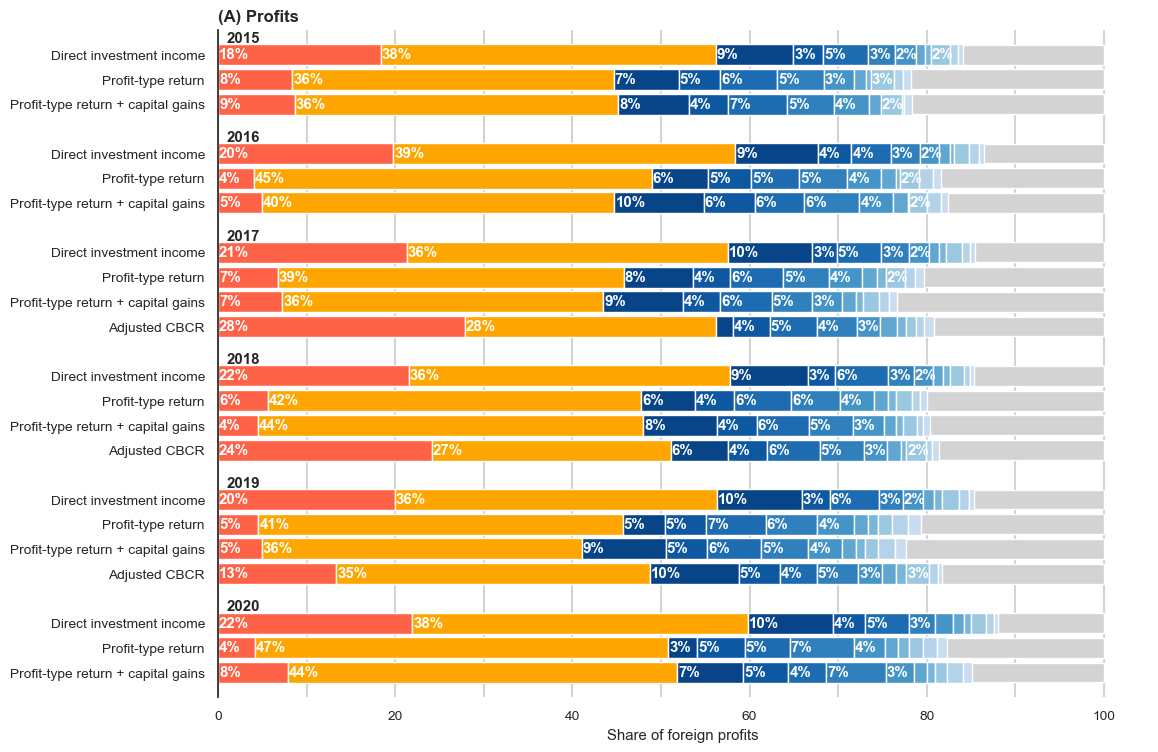

employees 5.333333333333333


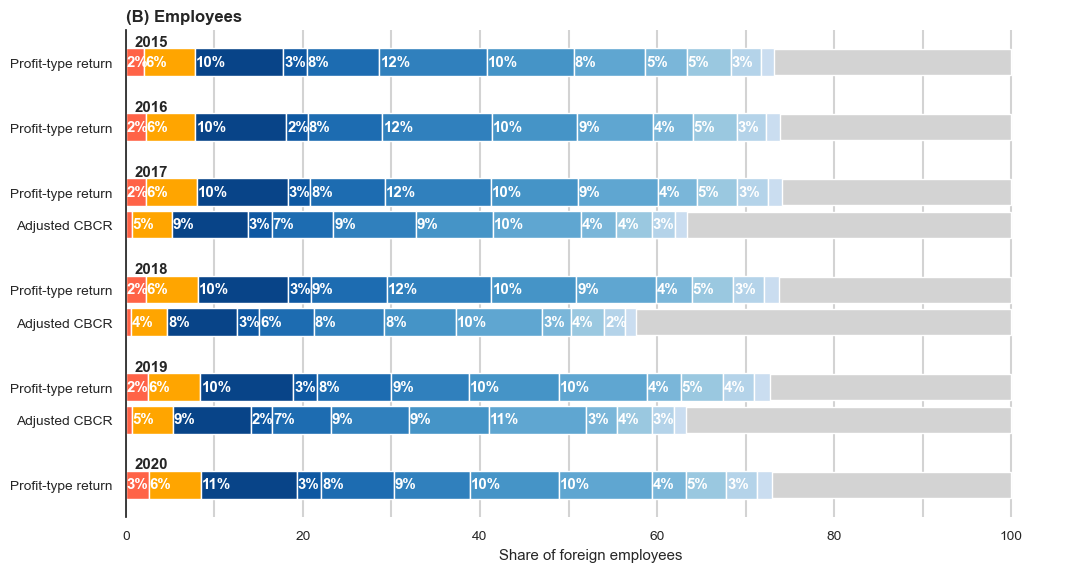

tangible assets 5.333333333333333


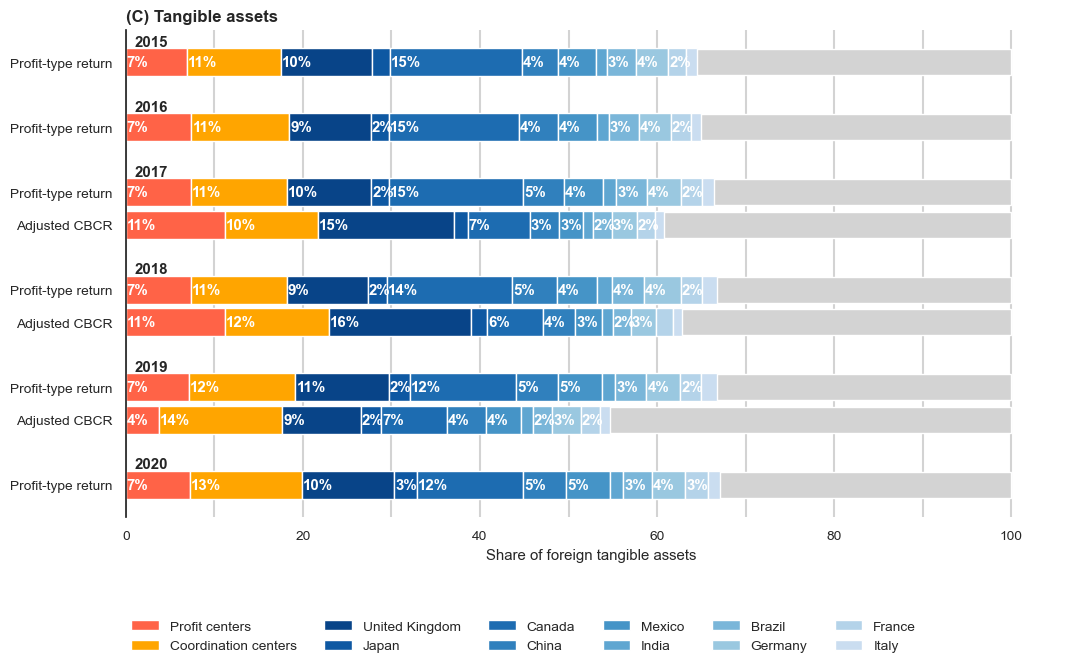

total assets 4.333333333333333


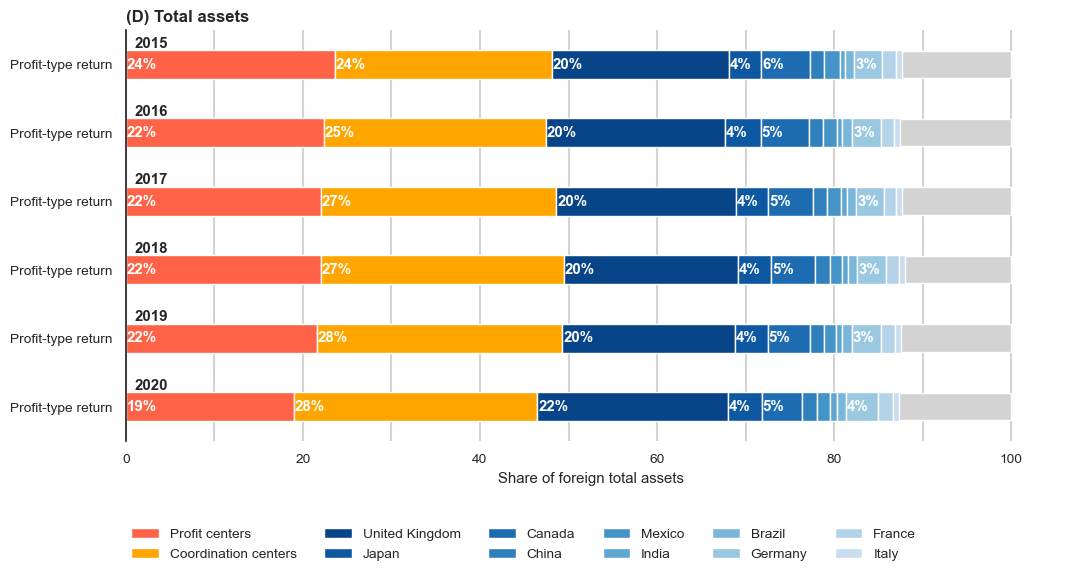

taxes 5.666666666666666


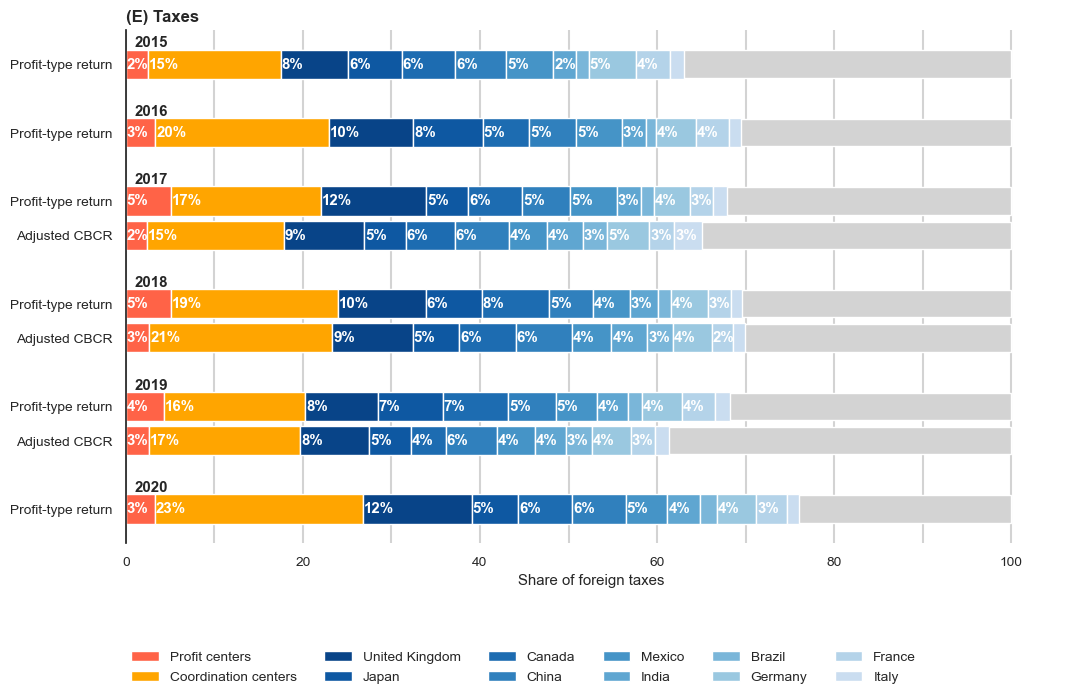

In [15]:
make_barplot(df,var="pi",letter="A",legend=False)
make_barplot(df,var="emp",letter="B",legend=False)
make_barplot(df,var="t_at",letter="C")
make_barplot(df,var="at",letter="D")
make_barplot(df,var="txt",letter="E")